In [ ]:
import pandas as pd                                                   # نرگس خواجه نظر
import numpy as np
df = pd.read_csv("Bengaluru_House_Data.csv")


In [103]:
df.head()

,area_type,availability,location,size,society,total_sqft,bath,balcony,price
0,Super built-up Area,19-Dec,Electronic City Phase II,2 BHK,Coomee,1056,2.0,1.0,39.07
1,Plot Area,Ready To Move,Chikka Tirupathi,4 Bedroom,Theanmp,2600,5.0,3.0,120.00
2,Built-up Area,Ready To Move,Uttarahalli,3 BHK,NaN,1440,2.0,3.0,62.00
3,Super built-up Area,Ready To Move,Lingadheeranahalli,3 BHK,Soiewre,1521,3.0,1.0,95.00
4,Super built-up Area,Ready To Move,Kothanur,2 BHK,NaN,1200,2.0,1.0,51.00


In [104]:
df.dtypes

area_type        object
availability     object
location         object
size             object
society          object
total_sqft       object
bath            float64
balcony         float64
price           float64
dtype: object

In [105]:
df.isnull().sum()


area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [106]:
mode_location = df['location'].mode()[0]
df['location'].fillna(mode_location, inplace=True)


C:\Users\Asia Laptop\AppData\Local\Temp\ipykernel_14880\851608784.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['location'].fillna(mode_location, inplace=True)


In [107]:
mode_size = df['size'].mode()[0]
df['size'].fillna(mode_size, inplace=True)


C:\Users\Asia Laptop\AppData\Local\Temp\ipykernel_14880\4120553191.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['size'].fillna(mode_size, inplace=True)


In [108]:
mode_society = df['society'].mode()[0]
df['society'].fillna(mode_society, inplace=True)


C:\Users\Asia Laptop\AppData\Local\Temp\ipykernel_14880\2456220348.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['society'].fillna(mode_society, inplace=True)


In [109]:
median_bath = df['bath'].median()
df['bath'].fillna(median_bath, inplace=True)


C:\Users\Asia Laptop\AppData\Local\Temp\ipykernel_14880\1984114046.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['bath'].fillna(median_bath, inplace=True)


In [110]:
median_balcony = df['balcony'].median()
df['balcony'].fillna(median_balcony, inplace=True)


C:\Users\Asia Laptop\AppData\Local\Temp\ipykernel_14880\3187964170.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['balcony'].fillna(median_balcony, inplace=True)


In [111]:
df.isnull().sum()

area_type       0
availability    0
location        0
size            0
society         0
total_sqft      0
bath            0
balcony         0
price           0
dtype: int64

In [112]:
def convert_sqft_to_num(x):
    try:
        return float(x)
    except:
        if "-" in str(x):
            parts = x.split('-')
            if len(parts) == 2:
                return (float(parts[0]) + float(parts[1])) / 2
            
        if "Sq. Meter" in str(x):
            val = float(x.split("Sq.")[0])
            return val * 10.764   # تبدیل متر مزبع به فوت مربع
        

        if "Sq. Yard" in str(x):
            val = float(x.split("Sq.")[0])
            return val * 9        # تبدیل یارد مربع به فوت مربع

    
        return None


In [113]:
df['total_sqft'] = df['total_sqft'].apply(convert_sqft_to_num)
df['total_sqft'].isnull().sum()



np.int64(14)

In [114]:
df['total_sqft'].fillna(df['total_sqft'].median(), inplace=True)

C:\Users\Asia Laptop\AppData\Local\Temp\ipykernel_14880\292216345.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['total_sqft'].fillna(df['total_sqft'].median(), inplace=True)


In [115]:
df['price_per_sqft'] = df['price']*100000 / df['total_sqft']


In [116]:
numeric_cols = ['total_sqft', 'bath', 'balcony', 'price_per_sqft']


In [117]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


In [118]:
d1 = pd.get_dummies(df['area_type'], drop_first=True)
d2 = pd.get_dummies(df['availability'], drop_first=True)
d3 = pd.get_dummies(df['location'], drop_first=True)
d4 = pd.get_dummies(df['size'], drop_first=True)
d5 = pd.get_dummies(df['society'], drop_first=True)


In [119]:
df = pd.concat([df, d1, d2, d3, d4, d5], axis=1)


In [120]:
df.drop(['area_type', 'availability', 'location', 'size', 'society'], axis=1, inplace=True)


In [121]:
df.head()

,total_sqft,bath,balcony,price,price_per_sqft,Carpet Area,Plot Area,Super built-up Area,14-Nov,15-Aug,...,Xeitaa,YCnce R,YMhenLi,Yaenti,ZeodsWo,Zonce E,Zostaa,i1ncyRe,i1odsne,i1rtsCo
0,-0.392796,-0.514538,-0.751371,39.07,-0.039682,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0.790589,1.726436,1.739175,120.00,-0.031065,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,-0.098483,-0.514538,1.739175,62.00,-0.033981,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-0.036401,0.232453,-0.751371,95.00,-0.015718,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
4,-0.282429,-0.514538,-0.751371,51.00,-0.034504,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False


In [122]:
def cap_outliers_simple(df):
    mean = df['price_per_sqft'].mean()
    std = df['price_per_sqft'].std()
    lower = mean - std
    upper = mean + std
    df_copy = df.copy()
    df_copy.loc[df_copy['price_per_sqft'] < lower, 'price_per_sqft'] = mean
    df_copy.loc[df_copy['price_per_sqft'] > upper, 'price_per_sqft'] = mean
    return df_copy

df = cap_outliers_simple(df)


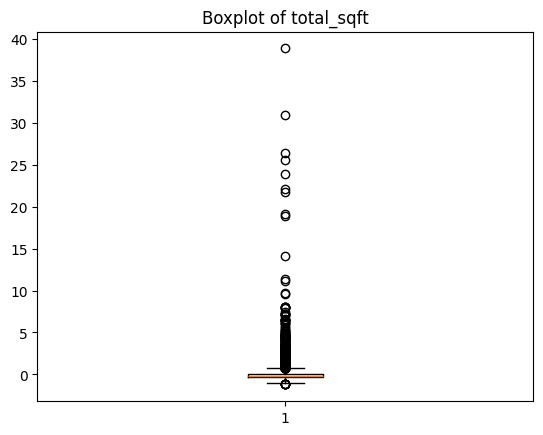

In [123]:
import matplotlib.pyplot as plt
plt.boxplot(df['total_sqft'])
plt.title('Boxplot of total_sqft')
plt.show()


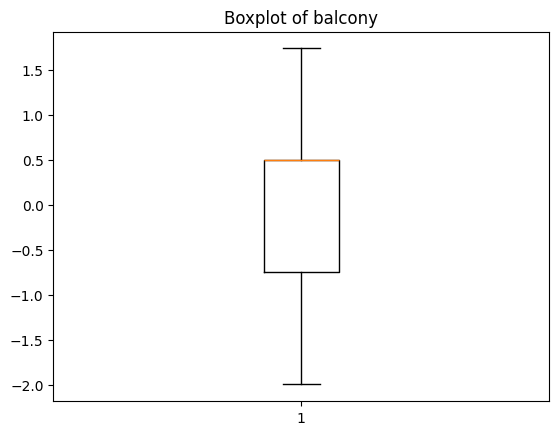

In [124]:
import matplotlib.pyplot as plt
plt.boxplot(df['balcony'])
plt.title('Boxplot of balcony')
plt.show()


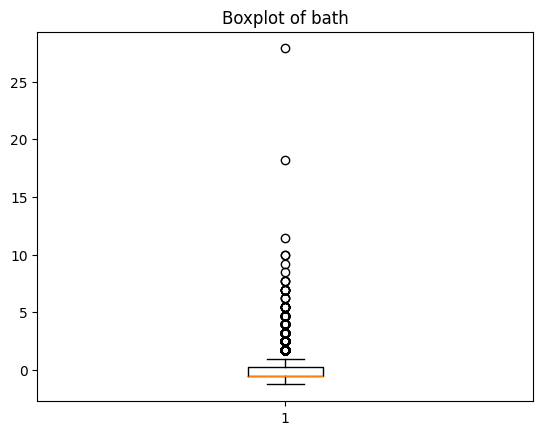

In [125]:
import matplotlib.pyplot as plt
plt.boxplot(df['bath'])
plt.title('Boxplot of bath')
plt.show()


In [126]:
numeric_cols = ['total_sqft', 'bath', 'balcony', 'price_per_sqft']
X_num = df[numeric_cols]
X_cat = df.drop(['price'] + numeric_cols, axis=1) 

scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X_num)

X = np.concatenate([X_num_scaled, X_cat.values], axis=1)
y = df['price']

print("داده‌ها آماده شدند. تعداد ویژگی‌ها:", X.shape[1])


داده‌ها آماده شدند. تعداد ویژگی‌ها: 4108


In [127]:
numeric_features = ['total_sqft', 'bath', 'balcony', 'price_per_sqft', 'price']
corr_with_price = df[numeric_features].corr()['price'].sort_values(ascending=False)

print("Correlation با price:")
print(corr_with_price.head(10))

low_corr = corr_with_price[corr_with_price.abs() < 0.05].index
print(low_corr.tolist())

Correlation با price:
price             1.000000
price_per_sqft    0.663104
total_sqft        0.546533
bath              0.454449
balcony           0.124951
Name: price, dtype: float64
[]


In [128]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE

X = df.drop(['price'], axis=1)
y = df['price']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

selector = SelectKBest(score_func=f_regression, k=5)
selector.fit(X_scaled, y)
selected_features = X.columns[selector.get_support()]

print("ویژگیهای انتخاب شده با F-regression:")
print(selected_features.tolist())

X_rfe = X[selected_features]
model = LinearRegression()
rfe = RFE(model, n_features_to_select=3)  
rfe.fit(X_rfe, y)

selected_rfe = X_rfe.columns[rfe.support_]
print("ویژگی‌های انتخاب شده با RFE:")
print(selected_rfe.tolist())


ویژگیهای انتخاب شده با F-regression:
['total_sqft', 'bath', 'price_per_sqft', 'Plot  Area', '2 BHK']
ویژگی‌های انتخاب شده با RFE:
['total_sqft', 'price_per_sqft', 'Plot  Area']


PCA explained variance ratio: [0.88558769 0.11325195]


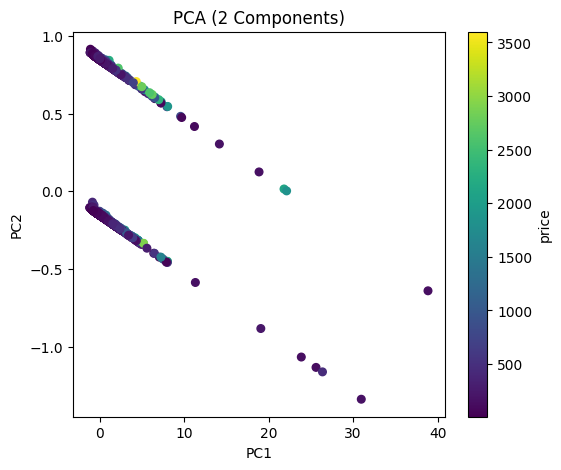

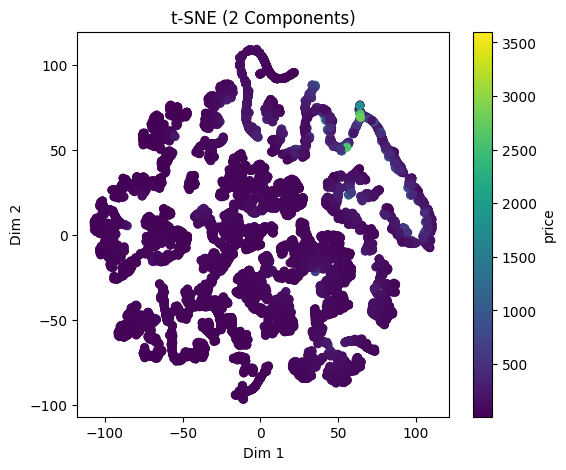

In [129]:
selected_rfe = ['total_sqft', 'price_per_sqft', 'Plot  Area']
X_model = df[selected_rfe]
y_model = df['price']

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_model)
print("PCA explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(6,5))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y_model, cmap='viridis', s=30)
plt.colorbar(label='price')
plt.title("PCA (2 Components)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_model)

plt.figure(figsize=(6,5))
plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y_model, cmap='viridis', s=30)
plt.colorbar(label='price')
plt.title("t-SNE (2 Components)")
plt.xlabel("Dim 1")
plt.ylabel("Dim 2")
plt.show()



f:\university\term7\ml\firstproject\fpr\fmlvenv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


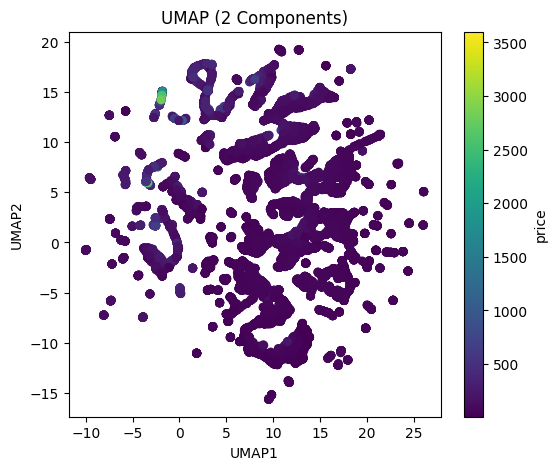

In [130]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components=2, random_state=42)
X_umap = reducer.fit_transform(X_model)

plt.figure(figsize=(6, 5))
plt.scatter(X_umap[:, 0], X_umap[:, 1], c=y_model, cmap='viridis', s=30)
plt.colorbar(label='price')
plt.title("UMAP (2 Components)")
plt.xlabel("UMAP1")
plt.ylabel("UMAP2")
plt.show()


 MSE scores (K=5): [ 5624.54333358  6001.565974    7965.637862    8469.54388284
 10639.78976393]
 Mean MSE: 7740.216163271127


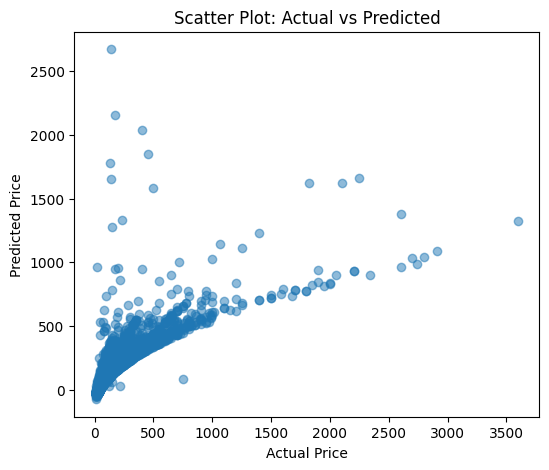

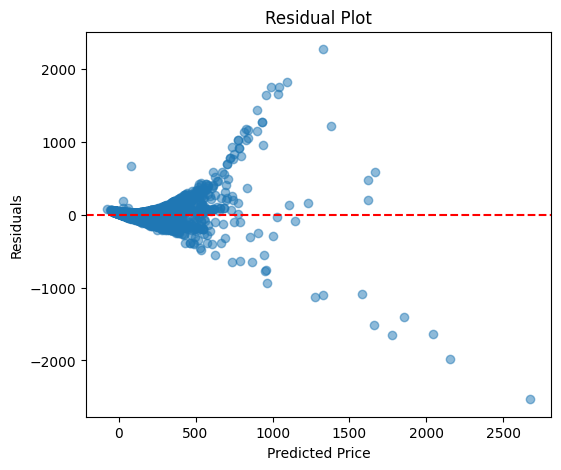

In [131]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, make_scorer
import numpy as np

model = LinearRegression()

kf = KFold(n_splits=5, shuffle=True, random_state=42)
mse_scorer = make_scorer(mean_squared_error)

mse_scores = cross_val_score(model, X_model, y_model, cv=kf, scoring=mse_scorer)
print(f" MSE scores (K=5):", mse_scores)
print(f" Mean MSE:", np.mean(mse_scores))


model.fit(X_model, y_model)
y_pred = model.predict(X_model)

plt.figure(figsize=(6,5))
plt.scatter(y_model, y_pred, alpha=0.5)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Scatter Plot: Actual vs Predicted")
plt.show()

residuals = y_model - y_pred
plt.figure(figsize=(6,5))
plt.scatter(y_pred, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()



In [132]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as SKPCA


X = X_model.values  # ['total_sqft', 'price_per_sqft', 'Plot  Area']
X = X.astype(float)
X_mean = np.mean(X, axis=0)
X_centered = X - X_mean
cov_matrix = np.cov(X_centered, rowvar=False)
eig_values, eig_vectors = np.linalg.eigh(cov_matrix)


sorted_idx = np.argsort(eig_values)[::-1]
eig_values = eig_values[sorted_idx]
eig_vectors = eig_vectors[:, sorted_idx]

explained_variance_ratio = eig_values / np.sum(eig_values)
cumulative_variance = np.cumsum(explained_variance_ratio)

num_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print("Explained Variance Ratio (Manual PCA):", explained_variance_ratio)
print("Cumulative Variance:", cumulative_variance)
print("Number of components for 95% variance:", num_components_95)

X_pca_manual = X_centered @ eig_vectors[:, :2]

sk_pca = SKPCA(n_components=X.shape[1])
X_pca_sklearn = sk_pca.fit_transform(X)
sk_explained_variance_ratio = sk_pca.explained_variance_ratio_

Explained Variance Ratio (Manual PCA): [0.88558769 0.11325195 0.00116036]
Cumulative Variance: [0.88558769 0.99883964 1.        ]
Number of components for 95% variance: 2


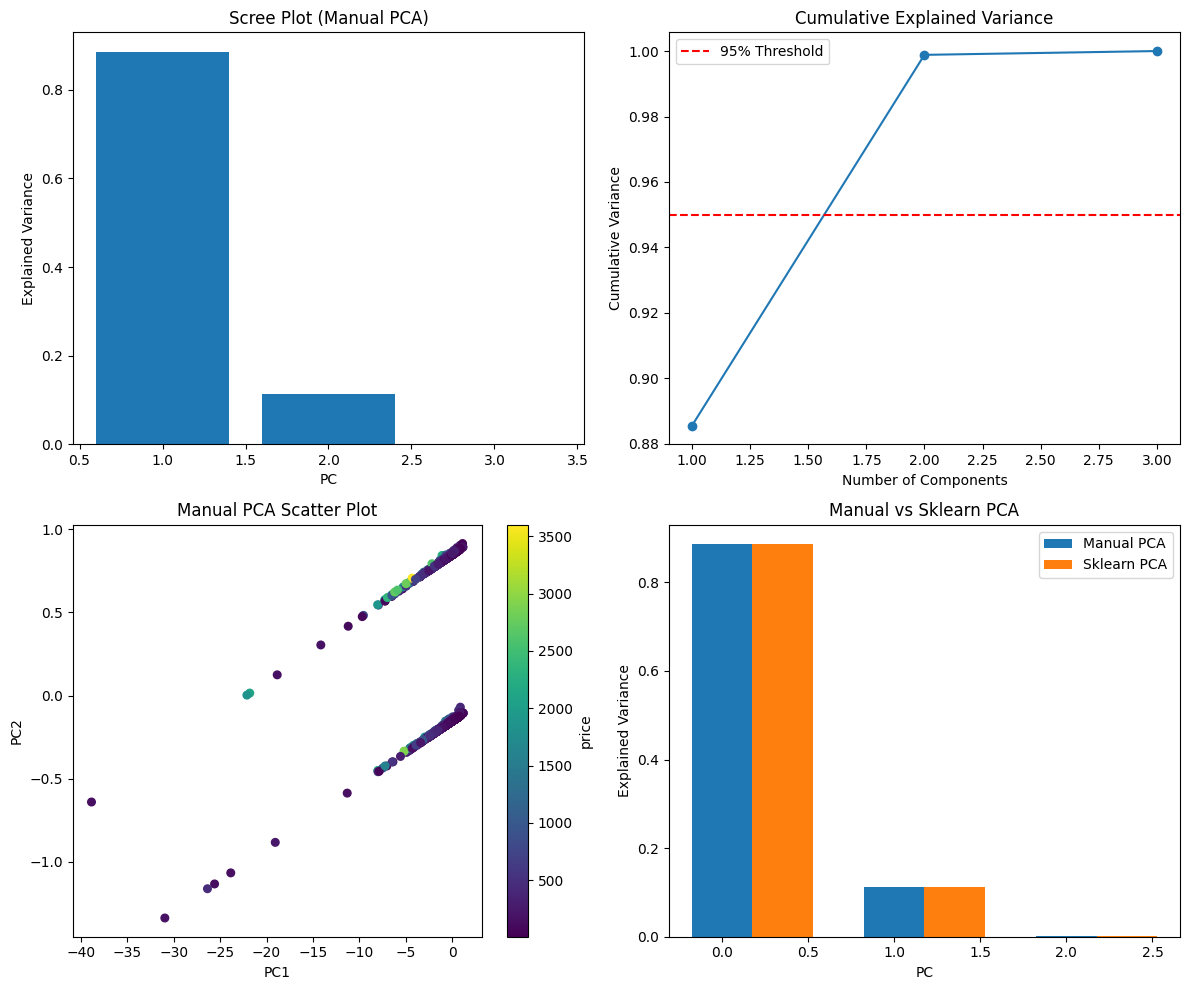

In [133]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 2, figsize=(12,10))  # 2 ردیف و 2 ستون


axs[0,0].bar(range(1, len(explained_variance_ratio)+1), explained_variance_ratio)
axs[0,0].set_title("Scree Plot (Manual PCA)")
axs[0,0].set_xlabel("PC")
axs[0,0].set_ylabel("Explained Variance")


axs[0,1].plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
axs[0,1].axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
axs[0,1].set_title("Cumulative Explained Variance")
axs[0,1].set_xlabel("Number of Components")
axs[0,1].set_ylabel("Cumulative Variance")
axs[0,1].legend()


scatter = axs[1,0].scatter(X_pca_manual[:,0], X_pca_manual[:,1], c=y_model, cmap='viridis', s=30)
axs[1,0].set_title("Manual PCA Scatter Plot")
axs[1,0].set_xlabel("PC1")
axs[1,0].set_ylabel("PC2")
fig.colorbar(scatter, ax=axs[1,0], label='price')


width = 0.35
indices = np.arange(len(explained_variance_ratio))
axs[1,1].bar(indices, explained_variance_ratio, width=width, label='Manual PCA')
axs[1,1].bar(indices + width, sk_explained_variance_ratio, width=width, label='Sklearn PCA')
axs[1,1].set_title("Manual vs Sklearn PCA")
axs[1,1].set_xlabel("PC")
axs[1,1].set_ylabel("Explained Variance")
axs[1,1].legend()

plt.tight_layout()
plt.show()
